Loaded 510036 rows. Columns: ['i', 'j', 'k', 'x_km', 'y_km', 'z_km', 'method', 'ntemp', 'alpha_s', 'lx_km', 'ly_km', 'lz_km', 'yo', 'yo_clean', 'hxf_mean', 'hxa_mean', 'dep_b', 'dep_a']
Departures extracted successfully.
Generating plot...


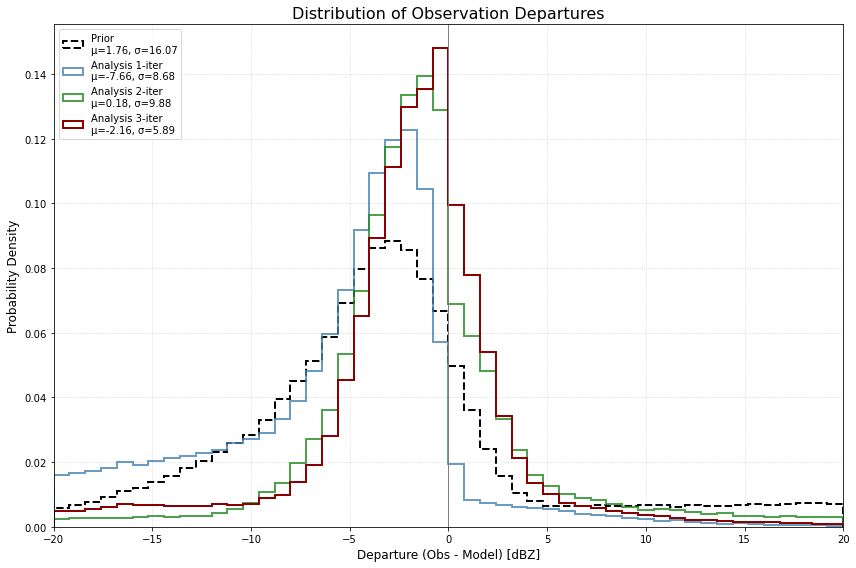

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

#----------------------------------------------------------------------
## 1. USER CONFIGURATION
#----------------------------------------------------------------------
base_path = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS1_sweep_hydra/"
file = "WS1_sweep_sweep_Ne040_tm00.npz"
filepath = os.path.join(base_path, file)

# Plotting parameters
hist_bins = 50
hist_range = (-20, 20)

#----------------------------------------------------------------------
## 2. LOAD DATA
#----------------------------------------------------------------------
data = np.load(filepath, allow_pickle=True)

# var_names is (9,) -- keep separately
var_names = data['var_names']

# 2D per-obs-per-var arrays (510036, 9) -- keep as numpy
rmse_f     = data['rmse_f']
rmse_a     = data['rmse_a']
spread_f   = data['spread_f']
spread_a   = data['spread_a']
rmse_f_w   = data['rmse_f_w']
rmse_a_w   = data['rmse_a_w']
spread_f_w = data['spread_f_w']
spread_a_w = data['spread_a_w']

# 1D per-obs columns -> DataFrame
cols_1d = [k for k in data.files if data[k].ndim == 1 and data[k].shape[0] != 9]
df = pd.DataFrame({k: data[k] for k in cols_1d})
print(f"Loaded {len(df)} rows. Columns: {list(df.columns)}")

#----------------------------------------------------------------------
## 3. EXTRACT DEPARTURES
#----------------------------------------------------------------------
df_tenkf = df[df['method'] == 'TEnKF']

df_1 = df_tenkf[df_tenkf['ntemp'] == 1]
df_2 = df_tenkf[df_tenkf['ntemp'] == 2]
df_3 = df_tenkf[df_tenkf['ntemp'] == 3]

# Prior departure (O-B) is the same for all ntemp -- take from ntemp==1
deps_prior = df_1['dep_b'].values
deps_1 = df_1['dep_a'].values
deps_2 = df_2['dep_a'].values
deps_3 = df_3['dep_a'].values

print("Departures extracted successfully.")

#----------------------------------------------------------------------
## 4. CREATE THE PLOT
#----------------------------------------------------------------------
print("Generating plot...")

fig, ax = plt.subplots(figsize=(12, 8))

ax.hist(deps_prior, bins=hist_bins, range=hist_range,
        density=True, histtype='step', linewidth=2,
        label=f'Prior \nμ={deps_prior.mean():.2f}, σ={deps_prior.std():.2f}',
        color='black', linestyle='--')

ax.hist(deps_1, bins=hist_bins, range=hist_range,
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 1-iter \nμ={deps_1.mean():.2f}, σ={deps_1.std():.2f}',
        color='SteelBlue', alpha=0.8)

ax.hist(deps_2, bins=hist_bins, range=hist_range,
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 2-iter \nμ={deps_2.mean():.2f}, σ={deps_2.std():.2f}',
        color='ForestGreen', alpha=0.8)

ax.hist(deps_3, bins=hist_bins, range=hist_range,
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 3-iter \nμ={deps_3.mean():.2f}, σ={deps_3.std():.2f}',
        color='DarkRed', alpha=1.0)

ax.set_title('Distribution of Observation Departures', fontsize=16)
ax.set_xlabel('Departure (Obs - Model) [dBZ]', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(hist_range)
ax.axvline(0, color='gray', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

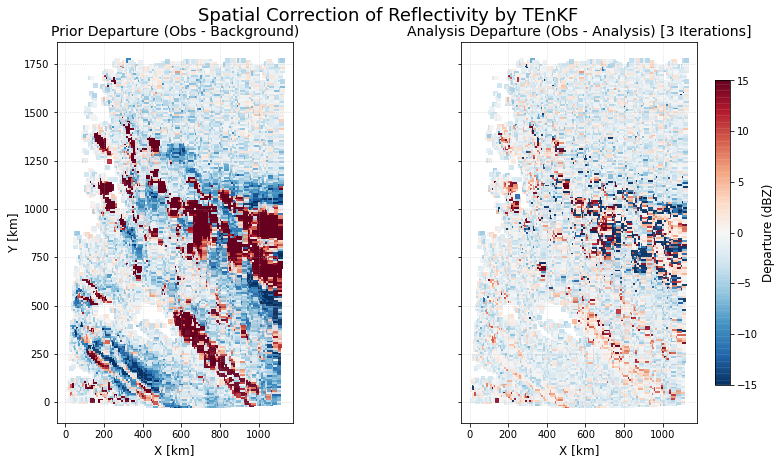

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select the data for the final iteration (3 steps)
df_plot = df_tenkf[df_tenkf['ntemp'] == 3].copy()
# Optional: filter by vertical level, e.g. z_km == 2.5
# df_plot = df_plot[df_plot['z_km'] == df_plot['z_km'].unique()[4]]

# 2. Set up a diverging colormap centered at zero
cmap = 'RdBu_r'
vmin, vmax = -15, 15

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# --- Plot 1: Prior Departure (O-B) ---
sc1 = axes[0].scatter(df_plot['x_km'], df_plot['y_km'],
                      c=df_plot['dep_b'], cmap=cmap, vmin=vmin, vmax=vmax,
                      s=15, marker='s', alpha=0.9)
axes[0].set_title('Prior Departure (Obs - Background)', fontsize=14)
axes[0].set_xlabel('X [km]', fontsize=12)
axes[0].set_ylabel('Y [km]', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.5)

# --- Plot 2: Analysis Departure (O-A) ---
sc2 = axes[1].scatter(df_plot['x_km'], df_plot['y_km'],
                      c=df_plot['dep_a'], cmap=cmap, vmin=vmin, vmax=vmax,
                      s=15, marker='s', alpha=0.9)
axes[1].set_title('Analysis Departure (Obs - Analysis) [3 Iterations]', fontsize=14)
axes[1].set_xlabel('X [km]', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.5)

cbar = fig.colorbar(sc2, ax=axes.ravel().tolist(), pad=0.02, shrink=0.8)
cbar.set_label('Departure (dBZ)', fontsize=12)

axes[0].set_aspect('equal')
axes[1].set_aspect('equal')

plt.suptitle('Spatial Correction of Reflectivity by TEnKF', fontsize=18, y=0.95)
plt.show()

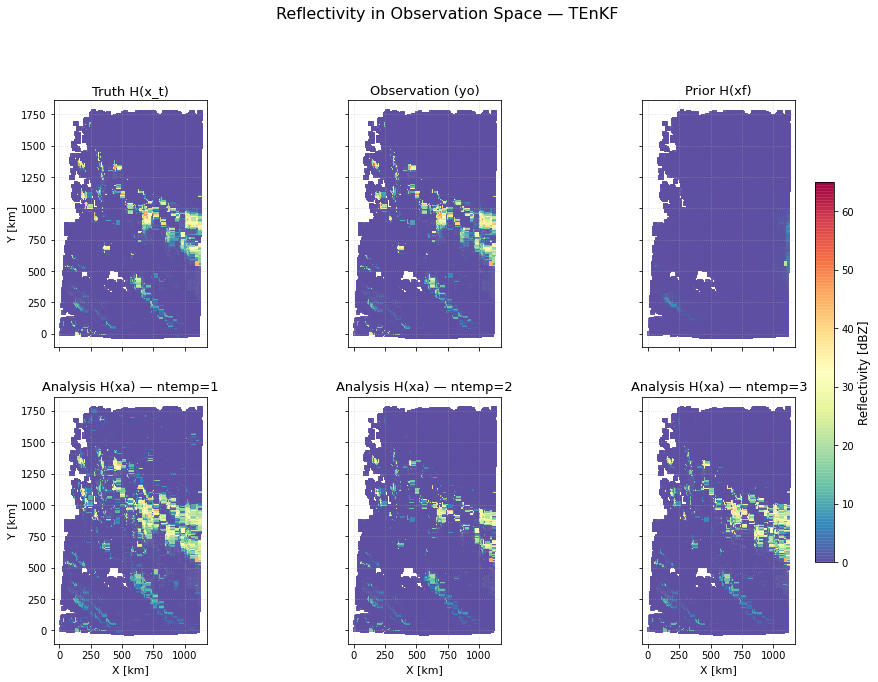

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Select ntemp==1 for the invariant fields, and all three for hxa_mean
df_1 = df_tenkf[df_tenkf['ntemp'] == 1].copy()
df_2 = df_tenkf[df_tenkf['ntemp'] == 2].copy()
df_3 = df_tenkf[df_tenkf['ntemp'] == 3].copy()

cmap = 'Spectral_r'
vmin, vmax = 0, 65  # dBZ range

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

def scatter_panel(ax, df, col, title):
    sc = ax.scatter(df['x_km'], df['y_km'],
                    c=df[col], cmap=cmap, vmin=vmin, vmax=vmax,
                    s=15, marker='s', alpha=0.9)
    ax.set_title(title, fontsize=13)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_aspect('equal')
    return sc

# Row 1: invariant fields
scatter_panel(axes[0, 0], df_1, 'yo_clean', 'Truth H(x_t)')
scatter_panel(axes[0, 1], df_1, 'yo',       'Observation (yo)')
scatter_panel(axes[0, 2], df_1, 'hxf_mean', 'Prior H(xf)')

# Row 2: analysis per ntemp
scatter_panel(axes[1, 0], df_1, 'hxa_mean', 'Analysis H(xa) — ntemp=1')
scatter_panel(axes[1, 1], df_2, 'hxa_mean', 'Analysis H(xa) — ntemp=2')
sc = scatter_panel(axes[1, 2], df_3, 'hxa_mean', 'Analysis H(xa) — ntemp=3')

# Axis labels
for ax in axes[1, :]:
    ax.set_xlabel('X [km]', fontsize=11)
for ax in axes[:, 0]:
    ax.set_ylabel('Y [km]', fontsize=11)

# Single colorbar
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), pad=0.02, shrink=0.7)
cbar.set_label('Reflectivity [dBZ]', fontsize=12)

plt.suptitle('Reflectivity in Observation Space — TEnKF', fontsize=16, y=1.01)
#plt.tight_layout()
plt.show()

In [46]:
print(f"dep_b mean: {df_1['dep_b'].mean():.2f} dBZ")
print(f"dep_b median: {df_1['dep_b'].median():.2f} dBZ")

dep_b mean: 1.76 dBZ
dep_b median: -2.71 dBZ
